# VGG-Net

## Imports

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imagenette/imagenette2/imagenette2/noisy_imagenette.csv
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_8421.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_4681.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_29670.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_6380.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_14790.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_4490.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_8580.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_32420.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_12111.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_8572.JPEG
/kaggle/input/imagenette/imagenette2/imagenette2/val/n01440764/n01440764_27451.JPEG
/kaggle/inpu

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Models

### Configuration A

In [3]:
class VGGNet_A(nn.Module):
    def __init__(self, output_classes):
        super(VGGNet_A, self).__init__()

        self.output_classes = output_classes
        
        self.activation = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.2)

        #First Conv Layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)

        #Second Conv Layer
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)

        #Third Conv Layer
        self.conv3a = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3b = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)

        #Fourth Conv Layer
        self.conv4a = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv4b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)

        #Fifth Conv Layer
        self.conv5a = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv5b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(512 * 7 * 7, 4096) ## Size becomes out_channel * W/2 * H/2
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, self.output_classes)

        #Sequential Block
        self.network = nn.Sequential(
            #First Conv Block
            self.conv1,
            self.activation,
            self.pool,
            #Second Conv Block
            self.conv2,
            self.activation,
            self.pool,
            #Third Conv Block
            self.conv3a,
            self.activation,
            self.conv3b,
            self.activation,
            self.pool,
            #Fourth Conv Block
            self.conv4a,
            self.activation,
            self.conv4b,
            self.activation,
            self.pool,
            #Fifth Conv Block
            self.conv5a,
            self.activation,
            self.conv5b,
            self.activation,
            self.pool,
        )
        self.apply(init_kaiming)

    def forward(self, X):
        X = self.network(X)
        X = torch.flatten(X, 1)
        X = self.fc1(X)
        X = self.dropout(X)
        X = self.fc2(X)
        X = self.dropout(X)
        X = self.fc3(X)
        return X

### Configuration A-LRN

In [4]:
class VGGNet_A_LRN(nn.Module):
    def __init__(self, output_classes):
        super(VGGNet_A_LRN, self).__init__()

        self.output_classes = output_classes
        
        self.activation = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.norm = nn.LocalResponseNorm(5, alpha=1e-4, beta=0.75, k=2)
        self.dropout = nn.Dropout(p=0.2)

        #First Conv Layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)

        #Second Conv Layer
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)

        #Third Conv Layer
        self.conv3a = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3b = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)

        #Fourth Conv Layer
        self.conv4a = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv4b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)

        #Fifth Conv Layer
        self.conv5a = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv5b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(512 * 7 * 7, 4096) ## Size becomes out_channel * W/2 * H/2
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, self.output_classes)

        #Sequential Block
        self.network = nn.Sequential(
            #First Conv Block
            self.conv1,
            self.activation,
            self.norm,
            self.pool,
            #Second Conv Block
            self.conv2,
            self.activation,
            self.pool,
            #Third Conv Block
            self.conv3a,
            self.activation,
            self.conv3b,
            self.activation,
            self.pool,
            #Fourth Conv Block
            self.conv4a,
            self.activation,
            self.conv4b,
            self.activation,
            self.pool,
            #Fifth Conv Block
            self.conv5a,
            self.activation,
            self.conv5b,
            self.activation,
            self.pool,
        )
        self.apply(init_kaiming)

    def forward(self, X):
        X = self.network(X)
        X = torch.flatten(X, 1)
        X = self.fc1(X)
        X = self.dropout(X)
        X = self.fc2(X)
        X = self.dropout(X)
        X = self.fc3(X)
        return X

### Configuration B

In [5]:
class VGGNet_B(nn.Module):
    def __init__(self, output_classes):
        super(VGGNet_B, self).__init__()

        self.output_classes = output_classes
        
        self.activation = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.2)
        
        #First Conv Layer
        self.conv1a = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv1b = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)

        #Second Conv Layer
        self.conv2a = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv2b = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1)

        #Third Conv Layer
        self.conv3a = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3b = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)

        #Fourth Conv Layer
        self.conv4a = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv4b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)

        #Fifth Conv Layer
        self.conv5a = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv5b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(512 * 7 * 7, 4096) ## Size becomes out_channel * W/2 * H/2
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, self.output_classes)

        #Sequential Block
        self.network = nn.Sequential(
            #First Conv Block
            self.conv1a,
            self.activation,
            self.conv1b,
            self.activation,
            self.pool,
            #Second Conv Block
            self.conv2a,
            self.activation,
            self.conv2b,
            self.activation,
            self.pool,
            #Third Conv Block
            self.conv3a,
            self.activation,
            self.conv3b,
            self.activation,
            self.pool,
            #Fourth Conv Block
            self.conv4a,
            self.activation,
            self.conv4b,
            self.activation,
            self.pool,
            #Fifth Conv Block
            self.conv5a,
            self.activation,
            self.conv5b,
            self.activation,
            self.pool,
        )

        self.apply(init_kaiming)

    def forward(self, X):
        X = self.network(X)
        X = torch.flatten(X, 1)
        X = self.fc1(X)
        X = self.dropout(X)
        X = self.fc2(X)
        X = self.dropout(X)
        X = self.fc3(X)
        return X

### Configuration C

In [6]:
class VGGNet_C(nn.Module):
    def __init__(self, output_classes):
        super(VGGNet_C, self).__init__()

        self.output_classes = output_classes
        
        self.activation = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.2)

        #First Conv Layer
        self.conv1a = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv1b = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)

        #Second Conv Layer
        self.conv2a = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv2b = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1)

        #Third Conv Layer
        self.conv3a = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3b = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3c = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=1, stride=1, padding=0)

        #Fourth Conv Layer
        self.conv4a = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv4b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv4c = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=1, stride=1, padding=0)

        #Fifth Conv Layer
        self.conv5a = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv5b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv5c = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=1, stride=1, padding=0)

        # Fully Connected Layers
        self.fc1 = nn.Linear(512 * 7 * 7, 4096) ## Size becomes out_channel * W/2 * H/2
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, self.output_classes)

        #Sequential Block
        self.network = nn.Sequential(
            #First Conv Block
            self.conv1a,
            self.activation,
            self.conv1b,
            self.activation,
            self.pool,
            #Second Conv Block
            self.conv2a,
            self.activation,
            self.conv2b,
            self.activation,
            self.pool,
            #Third Conv Block
            self.conv3a,
            self.activation,
            self.conv3b,
            self.activation,
            self.conv3c,
            self.activation,
            self.pool,
            #Fourth Conv Block
            self.conv4a,
            self.activation,
            self.conv4b,
            self.activation,
            self.conv4c,
            self.activation,
            self.pool,
            #Fifth Conv Block
            self.conv5a,
            self.activation,
            self.conv5b,
            self.activation,
            self.conv5c,
            self.activation,
            self.pool,
        )

        self.apply(init_kaiming)

    def forward(self, X):
        X = self.network(X)
        X = torch.flatten(X, 1)
        X = self.fc1(X)
        X = self.dropout(X)
        X = self.fc2(X)
        X = self.dropout(X)
        X = self.fc3(X)
        return X

### Configuration D

In [7]:
class VGGNet_D(nn.Module):
    def __init__(self, output_classes):
        super(VGGNet_D, self).__init__()

        self.output_classes = output_classes
        
        self.activation = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.2)

        #First Conv Layer
        self.conv1a = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv1b = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)

        #Second Conv Layer
        self.conv2a = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv2b = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1)

        #Third Conv Layer
        self.conv3a = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3b = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3c = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)

        #Fourth Conv Layer
        self.conv4a = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv4b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv4c = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)

        #Fifth Conv Layer
        self.conv5a = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv5b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv5c = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(512 * 7 * 7, 4096) ## Size becomes out_channel * W/2 * H/2
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, self.output_classes)

        #Sequential Block
        self.network = nn.Sequential(
            #First Conv Block
            self.conv1a,
            self.activation,
            self.conv1b,
            self.activation,
            self.pool,
            #Second Conv Block
            self.conv2a,
            self.activation,
            self.conv2b,
            self.activation,
            self.pool,
            #Third Conv Block
            self.conv3a,
            self.activation,
            self.conv3b,
            self.activation,
            self.conv3c,
            self.activation,
            self.pool,
            #Fourth Conv Block
            self.conv4a,
            self.activation,
            self.conv4b,
            self.activation,
            self.conv4c,
            self.activation,
            self.pool,
            #Fifth Conv Block
            self.conv5a,
            self.activation,
            self.conv5b,
            self.activation,
            self.conv5c,
            self.activation,
            self.pool,
        )

        self.apply(init_kaiming)

    def forward(self, X):
        X = self.network(X)
        X = torch.flatten(X, 1)
        X = self.fc1(X)
        X = self.dropout(X)
        X = self.fc2(X)
        X = self.dropout(X)
        X = self.fc3(X)
        return X

### Configuration E

In [8]:
class VGGNet_E(nn.Module):
    def __init__(self, output_classes):
        super(VGGNet_E, self).__init__()

        self.output_classes = output_classes
        
        self.activation = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.2)

        #First Conv Layer
        self.conv1a = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv1b = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)

        #Second Conv Layer
        self.conv2a = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv2b = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1)

        #Third Conv Layer
        self.conv3a = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3b = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3c = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3d = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)

        #Fourth Conv Layer
        self.conv4a = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv4b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv4c = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv4d = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)

        #Fifth Conv Layer
        self.conv5a = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv5b = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv5c = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.conv5d = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(512 * 7 * 7, 4096) ## Size becomes out_channel * W/2 * H/2
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, self.output_classes)

        #Sequential Block
        self.network = nn.Sequential(
            #First Conv Block
            self.conv1a,
            self.activation,
            self.conv1b,
            self.activation,
            self.pool,
            #Second Conv Block
            self.conv2a,
            self.activation,
            self.conv2b,
            self.activation,
            self.pool,
            #Third Conv Block
            self.conv3a,
            self.activation,
            self.conv3b,
            self.activation,
            self.conv3c,
            self.activation,
            self.conv3d,
            self.activation,
            self.pool,
            #Fourth Conv Block
            self.conv4a,
            self.activation,
            self.conv4b,
            self.activation,
            self.conv4c,
            self.activation,
            self.conv4d,
            self.activation,
            self.pool,
            #Fifth Conv Block
            self.conv5a,
            self.activation,
            self.conv5b,
            self.activation,
            self.conv5c,
            self.activation,
            self.conv5d,
            self.activation,
            self.pool,
        )

        self.apply(init_kaiming)

    def forward(self, X):
        X = self.network(X)
        X = torch.flatten(X, 1)
        X = self.fc1(X)
        X = self.dropout(X)
        X = self.fc2(X)
        X = self.dropout(X)
        X = self.fc3(X)
        return X

## Dataset and Dataloader

### LightingPCA

In [9]:
class LightingPCA(object):
    def __init__(self, alpha_std=0.1):
        self.alpha_std = alpha_std
        self.eigvals = torch.tensor([0.2175, 0.0188, 0.0045])
        self.eigvecs = torch.tensor([
            [-0.5675,  0.7192,  0.4009],
            [-0.5808, -0.0045, -0.8140],
            [-0.5836, -0.6948,  0.4203]
        ])

    def __call__(self, img):
        """
        img: Tensor assumed to be shape (C, H, W), float in [0, 1].
        """
        if self.alpha_std == 0:
            return img

        # Sample random alpha from N(0, 0.1)
        alpha = torch.normal(mean=0.0, std=self.alpha_std, size=(3,))

        # Compute RGB noise
        rgb = (self.eigvecs @ (alpha * self.eigvals)).view(3, 1, 1)

        return img + rgb

### Transforms

In [10]:
imagenette_train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    LightingPCA(alpha_std=0.01),
])


imagenette_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

### Dataset

In [11]:
def download_Imagenette():
    train_dataset = ImageFolder(
        root=f"/kaggle/input/imagenette/imagenette2/imagenette2/train",
        transform=imagenette_train_transform
    )
    
    val_dataset = ImageFolder(
        root=f"/kaggle/input/imagenette/imagenette2/imagenette2/val",
        transform=imagenette_test_transform
    )
    
    return train_dataset, val_dataset

### DataLoader

In [12]:
def create_DataLoaders(train_dataset, test_dataset, batch_size, shuffle_train, num_workers):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, test_loader

## Training Configuration

### Initialization

In [13]:
def init_kaiming(module):
    """
    Kaiming (He) initialization for VGG-style networks.
    - Conv layers: Kaiming normal (fan_out, ReLU)
    - Linear layers: Kaiming normal
    - Biases: zero
    """

    if isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(
            module.weight,
            mode="fan_out",
            nonlinearity="relu"
        )
        if module.bias is not None:
            nn.init.zeros_(module.bias)

    elif isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(
            module.weight,
            nonlinearity="relu"
        )
        if module.bias is not None:
            nn.init.zeros_(module.bias)

### Metrics

In [14]:
def compute_topk_error(outputs, targets, topk=(1, 3, 5)):
    """
    Compute top-k classification ERROR in percentage terms.

    Args:
        outputs (Tensor): logits of shape (B, num_classes)
        targets (Tensor): ground-truth labels of shape (B,)
        topk (tuple): which top-k error rates to compute

    Returns:
        dict with keys: 'top{k}_error' (values in %)
    """
    maxk = max(topk)
    batch_size = targets.size(0)

    # Top-k predicted class indices
    _, pred = outputs.topk(maxk, dim=1, largest=True, sorted=True)
    pred = pred.t()  # (maxk, B)

    # Compare predictions with targets
    correct = pred.eq(targets.view(1, -1))  # (maxk, B)

    error_dict = {}

    for k in topk:
        # True if target appears anywhere in top-k
        correct_k = correct[:k].any(dim=0).float().sum().item()

        error_k = 100.0 * (1.0 - correct_k / batch_size)
        error_dict[f"top{k}_error"] = error_k

    return error_dict


### Epoch Training and Validation

In [15]:
def train_epoch(model, dataloader, criterion, optimizer, device, update_freq=10):
    model.train()
    pbar = tqdm(dataloader, desc="Train", leave=False)
    
    total_loss = 0.0
    total_top1_error = 0.0
    total_top3_error = 0.0
    total_top5_error = 0.0
    num_batches = 0

    for batch_idx, (features, labels) in enumerate(pbar):
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            errors = compute_topk_error(outputs, labels, topk=(1,3,5))

        total_loss += loss.item()
        total_top1_error += errors["top1_error"]
        total_top3_error += errors["top3_error"]
        total_top5_error += errors["top5_error"]
        num_batches += 1

        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'T1E': f'{errors["top1_error"]:.2f}',
            'T3E': f'{errors["top3_error"]:.2f}'
        })

    pbar.close()
    if num_batches == 0:
        return 0, 0, 0, 0
    return (total_loss / num_batches, total_top1_error / num_batches, 
            total_top3_error / num_batches, total_top5_error / num_batches)

In [16]:
def evaluate(model, dataloader, criterion, device, sanity_check=True):
    model.eval()
    pbar = tqdm(dataloader, desc="Eval ", leave=False)

    total_loss = 0.0
    total_top1_error = 0.0
    total_top3_error = 0.0
    total_top5_error = 0.0
    num_batches = 0

    # --- sanity accumulators (only for first batch) ---
    first_batch_checked = False

    with torch.no_grad():
        for features, labels in pbar:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            errors = compute_topk_error(outputs, labels, topk=(1,3,5))

            total_loss += loss.item()
            total_top1_error += errors["top1_error"]
            total_top3_error += errors["top3_error"]
            total_top5_error += errors["top5_error"]
            num_batches += 1

            # ---------------- SANITY CHECK ----------------
            if sanity_check and not first_batch_checked:
                logits_std = outputs.std().item()
                logits_mean = outputs.mean().item()
                pred_classes = outputs.argmax(dim=1)
                unique_preds = pred_classes.unique().numel()
                unique_labels = labels.unique().numel()

                print("\n[Sanity Check – Eval]")
                print(f"  Logits mean     : {logits_mean:.4f}")
                print(f"  Logits std      : {logits_std:.4f}")
                print(f"  Unique preds    : {unique_preds}")
                print(f"  Unique labels   : {unique_labels}")
                print(f"  Top-1 error     : {errors['top1_error']:.4f}")
                print("--------------------------------------------------")

                # Hard assertions (comment out once stable)
                assert logits_std > 0.01, "⚠️ Logits collapsed (near-uniform)"
                assert unique_preds > 1, "⚠️ Model predicts single class"
                #assert unique_labels > 1, "⚠️ Test batch has degenerate labels"

                first_batch_checked = True
            # ------------------------------------------------

            pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

    pbar.close()

    if num_batches == 0:
        return 0, 0, 0, 0

    return (
        total_loss / num_batches,
        total_top1_error / num_batches,
        total_top3_error / num_batches,
        total_top5_error / num_batches,
    )

### Main Training Loop

In [17]:
def train(num_epochs, model, train_dataloader, test_dataloader, criterion, optimizer, device, update_freq=10):
    train_losses, train_top1_errors, train_top3_errors, train_top5_errors = [], [], [], []
    test_losses, test_top1_errors, test_top3_errors, test_top5_errors = [], [], [], []

    start_time = time.time()
    epoch_pbar = tqdm(range(num_epochs), desc="Epochs")

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    for epoch in epoch_pbar:
        epoch_start_time = time.time()
        
        # Train
        train_loss, train_top1, train_top3, train_top5 = train_epoch(
            model, train_dataloader, criterion, optimizer, device, update_freq
        )
        scheduler.step()

        # Evaluate
        test_loss, test_top1, test_top3, test_top5 = evaluate(
            model, test_dataloader, criterion, device
        )

        # Store
        train_losses.append(train_loss); train_top1_errors.append(train_top1)
        train_top3_errors.append(train_top3); train_top5_errors.append(train_top5)
        test_losses.append(test_loss); test_top1_errors.append(test_top1)
        test_top3_errors.append(test_top3); test_top5_errors.append(test_top5)

        epoch_time = time.time() - epoch_start_time
        epoch_pbar.set_postfix({
            'Val T1E': f'{test_top1:.2f}', 
            'Time': f'{epoch_time:.0f}s'
        })

    total_time = time.time() - start_time
    print(f"\n✅ Done! Total: {total_time/60:.1f}min | Final Val T1E: {test_top1_errors[-1]:.2f}%")

    return (train_losses, train_top1_errors, train_top3_errors, train_top5_errors,
            test_losses, test_top1_errors, test_top3_errors, test_top5_errors)

## Model Initialization

In [18]:
model_A = VGGNet_A(output_classes=10).to(device)
model_C = VGGNet_C(output_classes=10).to(device)
model_D = VGGNet_D(output_classes=10).to(device)

In [19]:
total_params_A = sum(p.numel() for p in model_A.parameters())
total_params_C = sum(p.numel() for p in model_C.parameters())
total_params_D = sum(p.numel() for p in model_D.parameters())

total_params_A, total_params_C, total_params_D

(128807306, 129582922, 134301514)

### Configuration

In [20]:
train_dataset, test_dataset = download_Imagenette()

In [21]:
BATCH_SIZE = 64
NUM_WORKERS = 0

In [22]:
train_dataloader, test_dataloader = create_DataLoaders(
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        batch_size=BATCH_SIZE,
        shuffle_train=True,
        num_workers=NUM_WORKERS
    )

In [23]:
criterion = nn.CrossEntropyLoss()

In [24]:
decay, no_decay = [], []
for name, param in model_A.named_parameters():
    if not param.requires_grad:
        continue
    if name.endswith("bias"):
        no_decay.append(param)
    else:
        decay.append(param)

optimizer_A = torch.optim.SGD(
    [
        {"params": decay, "weight_decay": 5e-4},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=0.01,
    momentum=0.9,
)

In [25]:
decay, no_decay = [], []
for name, param in model_C.named_parameters():
    if not param.requires_grad:
        continue
    if name.endswith("bias"):
        no_decay.append(param)
    else:
        decay.append(param)

optimizer_C = torch.optim.SGD(
    [
        {"params": decay, "weight_decay": 5e-4},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=0.01,
    momentum=0.9,
)

In [26]:
decay, no_decay = [], []
for name, param in model_D.named_parameters():
    if not param.requires_grad:
        continue
    if name.endswith("bias"):
        no_decay.append(param)
    else:
        decay.append(param)

optimizer_D = torch.optim.SGD(
    [
        {"params": decay, "weight_decay": 5e-4},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=0.01,
    momentum=0.9,
)

### Visualization Utilities

In [27]:
import matplotlib.pyplot as plt

def plot_loss(train_losses, test_losses, save_path, label):
    epochs_range = range(1, len(train_losses) + 1)
    plt.plot(epochs_range, train_losses, 'b-o', label=f"Train {label}", linewidth=2, markersize=6)
    plt.plot(epochs_range, test_losses, 'r-s', label=f"Test {label}", linewidth=2, markersize=6)
    plt.xlabel('Epoch')
    plt.ylabel(label)
    plt.title(f"Train and Test {label}", fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300)  # dpi=300 gives high-quality image

    plt.show()

In [28]:
import matplotlib.pyplot as plt 
import numpy as np

def plot_accuracy(train_accuracies, test_accuracies, save_path):
    epochs_range = range(1, len(train_accuracies) + 1)
    plt.plot(epochs_range, train_accuracies, 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
    plt.plot(epochs_range, test_accuracies, 'r-s', label='Test Accuracy', linewidth=2, markersize=6)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Test Accuracy', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300)  # dpi=300 gives high-quality image

    plt.show()
    
def plot_accuracy_improvement(test_accuracies, save_path):
    epochs_range = range(1, len(test_accuracies) + 1)
    improvement = - np.array(test_accuracies) + test_accuracies[0]
    plt.bar(epochs_range, improvement, alpha=0.7, color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy Improvement (%)')
    plt.title('Test Accuracy Improvement', fontweight='bold')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
     # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300)  # dpi=300 gives high-quality image

    plt.show()

## Model A

### Training

In [42]:
A_train_losses, A_train_top1_errors, A_train_top3_errors, A_train_top5_errors, \
A_test_losses, A_test_top1_errors, A_test_top3_errors, A_test_top5_errors = train(
    num_epochs=30,
    model=model_A,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader, 
    criterion=criterion,
    optimizer=optimizer_A,  # Note: optimizer= (match train() param name)
    device=device,
    update_freq=10
)

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval :   0%|          | 0/62 [00:00<?, ?it/s]


[Sanity Check – Eval]
  Logits mean     : 0.0295
  Logits std      : 1.1173
  Unique preds    : 7
  Unique labels   : 1
  Top-1 error     : 26.5625
--------------------------------------------------


Train:   0%|          | 0/148 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/62 [00:00<?, ?it/s]


[Sanity Check – Eval]
  Logits mean     : 0.2175
  Logits std      : 6.7052
  Unique preds    : 5
  Unique labels   : 1
  Top-1 error     : 9.3750
--------------------------------------------------


Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval :   0%|          | 0/62 [00:00<?, ?it/s]


[Sanity Check – Eval]
  Logits mean     : 0.2192
  Logits std      : 6.7064
  Unique preds    : 4
  Unique labels   : 1
  Top-1 error     : 7.8125
--------------------------------------------------

✅ Done! Total: 95.9min | Final Val T1E: 16.84%


### Store

In [43]:
torch.save(model_A.state_dict(), "vggnet_config_A_weights.pth")

# Save full checkpoint
torch.save({
    'epoch': 30,
    'model_state_dict': model_A.state_dict(),
    'optimizer_state_dict': optimizer_A.state_dict(),
    'train_losses': A_train_losses,
    'train_top1_errors': A_train_top1_errors,
    'train_top3_errors': A_train_top3_errors,
    'train_top5_errors': A_train_top5_errors,
    'test_losses': A_test_losses,
    'test_top1_errors': A_test_top1_errors,
    'test_top3_errors': A_test_top3_errors,
    'test_top5_errors': A_test_top5_errors,
}, "vggnet_config_A_detailed.pth")

### Visualize Results

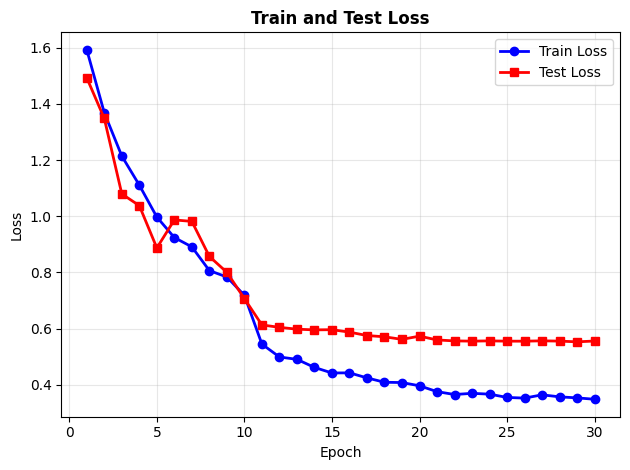

In [56]:
plot_loss(train_losses=A_train_losses, test_losses=A_test_losses, save_path="A_loss.png", label="Loss")

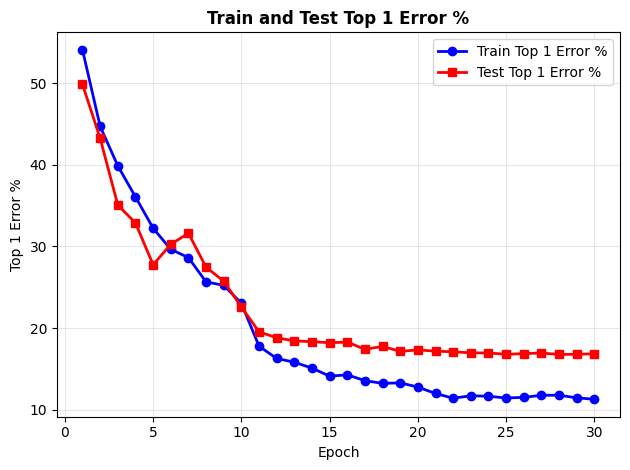

In [57]:
plot_loss(train_losses=A_train_top1_errors, test_losses=A_test_top1_errors, save_path="A_top1_errors.png", label="Top 1 Error %")

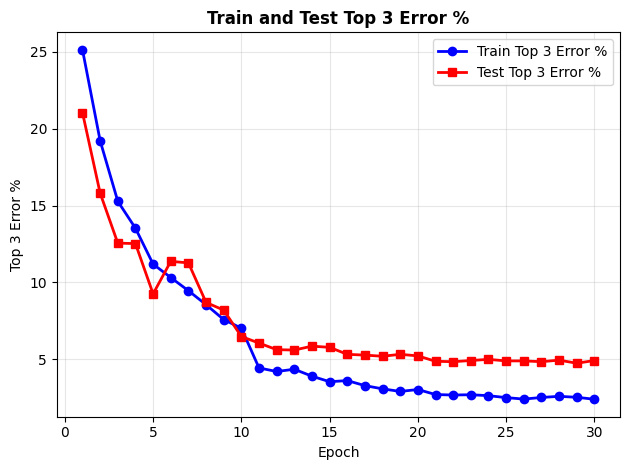

In [58]:
plot_loss(train_losses=A_train_top3_errors, test_losses=A_test_top3_errors, save_path="A_top3_errors.png", label="Top 3 Error %")

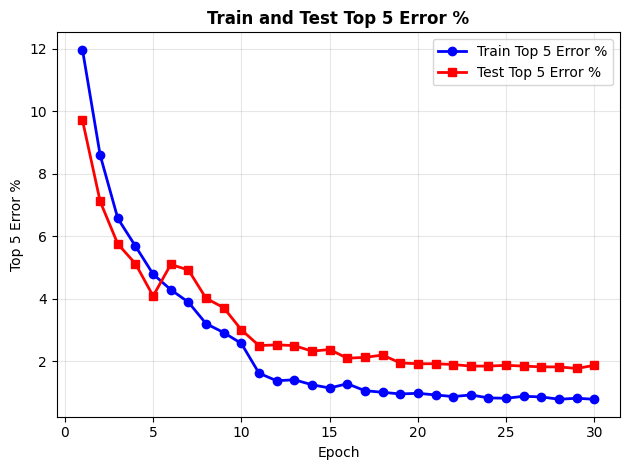

In [59]:
plot_loss(train_losses=A_train_top5_errors, test_losses=A_test_top5_errors, save_path="A_top5_errors.png", label="Top 5 Error %")

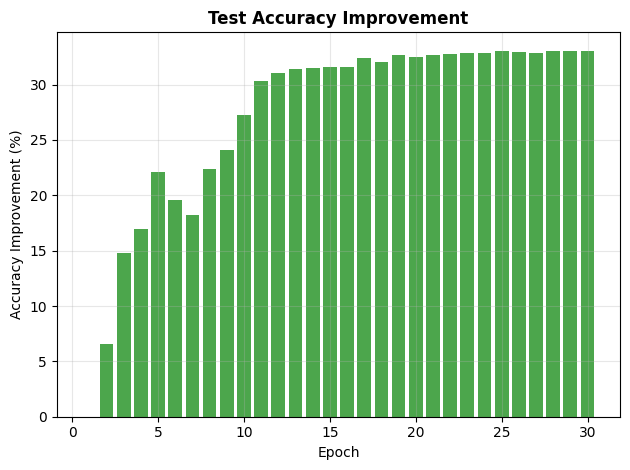

In [52]:
plot_accuracy_improvement(A_test_top1_errors, save_path="A_top1_error_improvement.png")

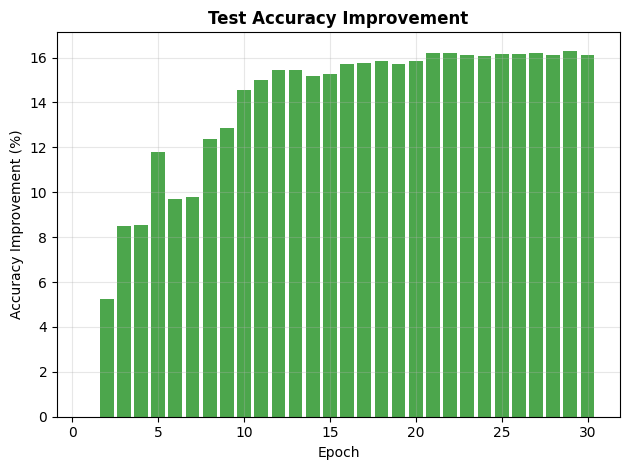

In [53]:
plot_accuracy_improvement(A_test_top3_errors, save_path="A_top3_error_improvement.png")

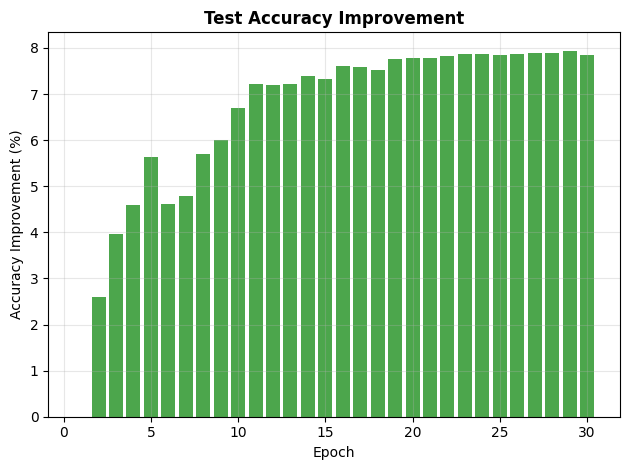

In [54]:
plot_accuracy_improvement(A_test_top5_errors, save_path="A_top5_error_improvement.png")

## Model C

### Training

In [29]:
C_train_losses, C_train_top1_errors, C_train_top3_errors, C_train_top5_errors, \
C_test_losses, C_test_top1_errors, C_test_top3_errors, C_test_top5_errors = train(
    num_epochs=30,
    model=model_C,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader, 
    criterion=criterion,
    optimizer=optimizer_C,  # Note: optimizer= (match train() param name)
    device=device,
    update_freq=10
)

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval :   0%|          | 0/62 [00:00<?, ?it/s]


[Sanity Check – Eval]
  Logits mean     : -0.0284
  Logits std      : 0.6821
  Unique preds    : 8
  Unique labels   : 1
  Top-1 error     : 59.3750
--------------------------------------------------


Train:   0%|          | 0/148 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/62 [00:00<?, ?it/s]


[Sanity Check – Eval]
  Logits mean     : 0.0567
  Logits std      : 4.2435
  Unique preds    : 5
  Unique labels   : 1
  Top-1 error     : 12.5000
--------------------------------------------------


Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval :   0%|          | 0/62 [00:00<?, ?it/s]


[Sanity Check – Eval]
  Logits mean     : 0.0583
  Logits std      : 4.3116
  Unique preds    : 5
  Unique labels   : 1
  Top-1 error     : 12.5000
--------------------------------------------------

✅ Done! Total: 127.0min | Final Val T1E: 20.50%


### Store

In [30]:
torch.save(model_C.state_dict(), "vggnet_config_C_weights.pth")

# Save full checkpoint
torch.save({
    'epoch': 30,
    'model_state_dict': model_C.state_dict(),
    'optimizer_state_dict': optimizer_C.state_dict(),
    'train_losses': C_train_losses,
    'train_top1_errors': C_train_top1_errors,
    'train_top3_errors': C_train_top3_errors,
    'train_top5_errors': C_train_top5_errors,
    'test_losses': C_test_losses,
    'test_top1_errors': C_test_top1_errors,
    'test_top3_errors': C_test_top3_errors,
    'test_top5_errors': C_test_top5_errors,
}, "vggnet_config_C_detailed.pth")

### Visualize Results

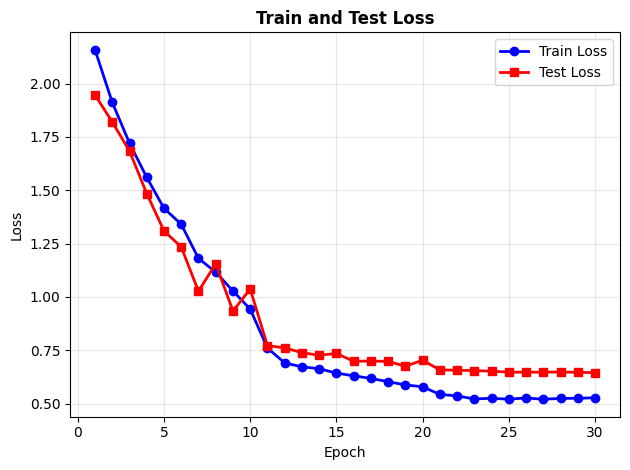

In [31]:
plot_loss(train_losses=C_train_losses, test_losses=C_test_losses, save_path="C_loss.png", label="Loss")

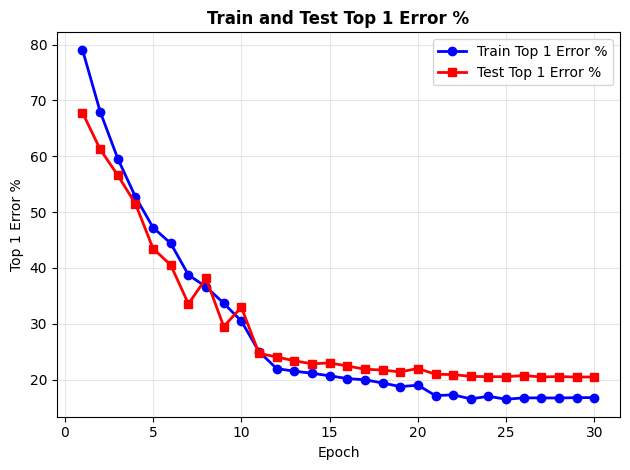

In [33]:
plot_loss(train_losses=C_train_top1_errors, test_losses=C_test_top1_errors, save_path="C_top1_errors.png", label="Top 1 Error %")

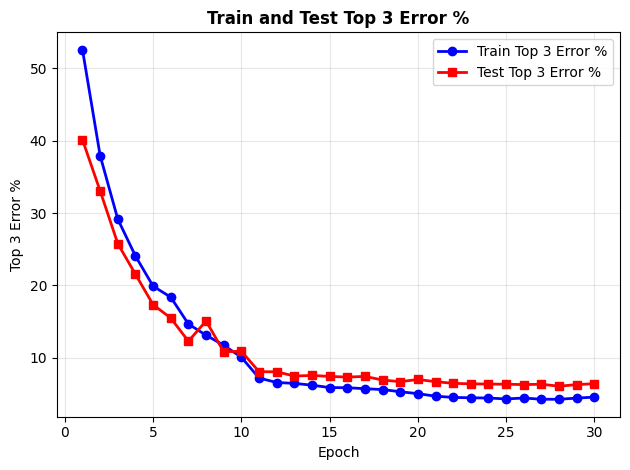

In [34]:
plot_loss(train_losses=C_train_top3_errors, test_losses=C_test_top3_errors, save_path="C_top3_errors.png", label="Top 3 Error %")

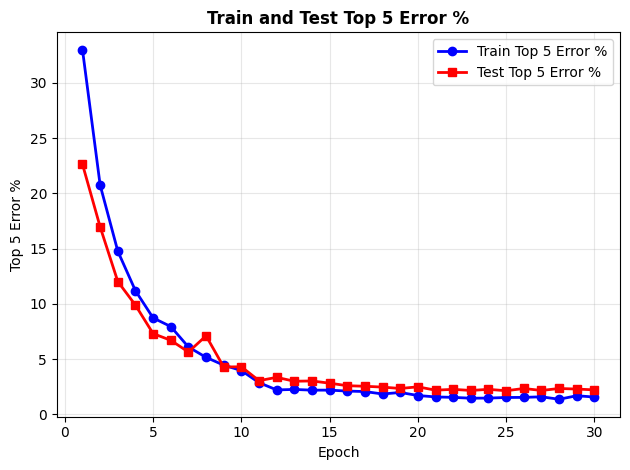

In [35]:
plot_loss(train_losses=C_train_top5_errors, test_losses=C_test_top5_errors, save_path="C_top5_errors.png", label="Top 5 Error %")

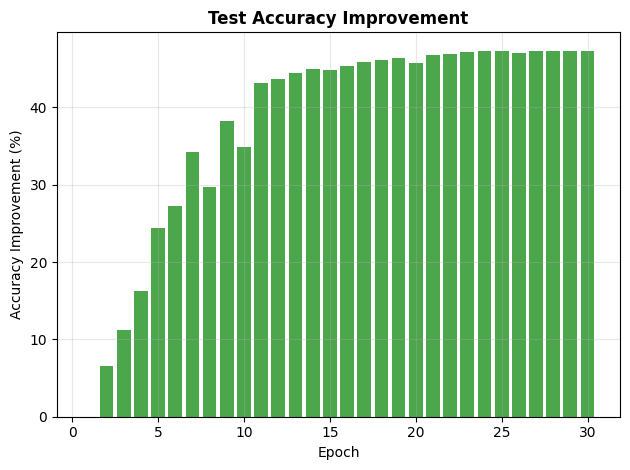

In [36]:
plot_accuracy_improvement(C_test_top1_errors, save_path="C_top1_error_improvement.png")

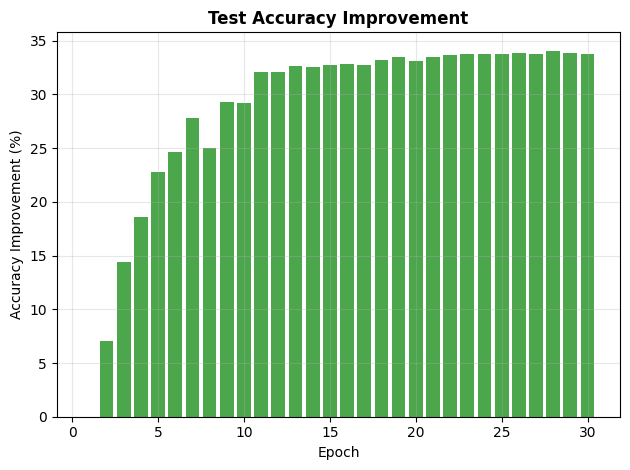

In [37]:
plot_accuracy_improvement(C_test_top3_errors, save_path="C_top3_error_improvement.png")

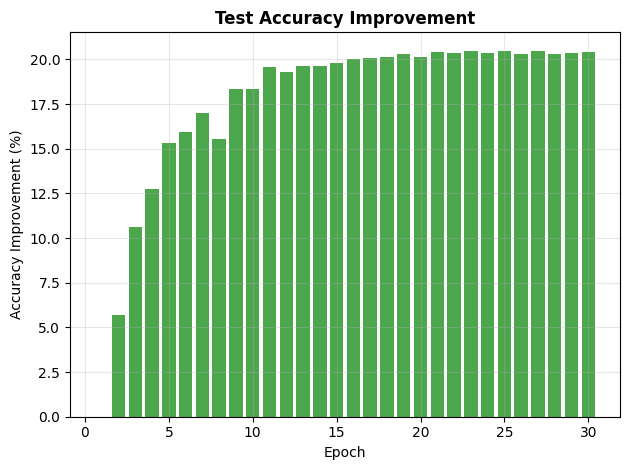

In [38]:
plot_accuracy_improvement(C_test_top5_errors, save_path="C_top5_error_improvement.png")

## Model D

### Training

In [39]:
D_train_losses, D_train_top1_errors, D_train_top3_errors, D_train_top5_errors, \
D_test_losses, D_test_top1_errors, D_test_top3_errors, D_test_top5_errors = train(
    num_epochs=35,
    model=model_D,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader, 
    criterion=criterion,
    optimizer=optimizer_D,  # Note: optimizer= (match train() param name)
    device=device,
    update_freq=10
)

Epochs:   0%|          | 0/35 [00:00<?, ?it/s]

Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval :   0%|          | 0/62 [00:00<?, ?it/s]


[Sanity Check – Eval]
  Logits mean     : 0.0049
  Logits std      : 0.6186
  Unique preds    : 7
  Unique labels   : 1
  Top-1 error     : 39.0625
--------------------------------------------------


Train:   0%|          | 0/148 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/62 [00:00<?, ?it/s]


[Sanity Check – Eval]
  Logits mean     : 0.0360
  Logits std      : 4.3119
  Unique preds    : 7
  Unique labels   : 1
  Top-1 error     : 12.5000
--------------------------------------------------


Train:   0%|          | 0/148 [00:00<?, ?it/s]

Eval :   0%|          | 0/62 [00:00<?, ?it/s]


[Sanity Check – Eval]
  Logits mean     : 0.0355
  Logits std      : 4.2917
  Unique preds    : 7
  Unique labels   : 1
  Top-1 error     : 12.5000
--------------------------------------------------

✅ Done! Total: 157.6min | Final Val T1E: 21.91%


### Store

In [40]:
torch.save(model_D.state_dict(), "vggnet_config_D_weights.pth")

# Save full checkpoint
torch.save({
    'epoch': 35,
    'model_state_dict': model_D.state_dict(),
    'optimizer_state_dict': optimizer_D.state_dict(),
    'train_losses': D_train_losses,
    'train_top1_errors': D_train_top1_errors,
    'train_top3_errors': D_train_top3_errors,
    'train_top5_errors': D_train_top5_errors,
    'test_losses': D_test_losses,
    'test_top1_errors': D_test_top1_errors,
    'test_top3_errors': D_test_top3_errors,
    'test_top5_errors': D_test_top5_errors,
}, "vggnet_config_D_detailed.pth")

### Visualize Results

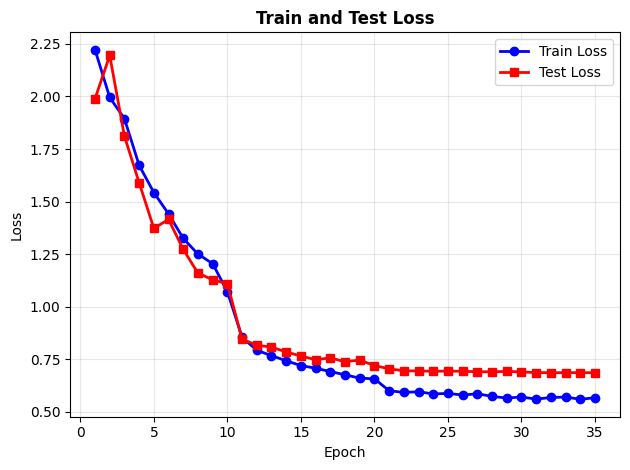

In [41]:
plot_loss(train_losses=D_train_losses, test_losses=D_test_losses, save_path="D_loss.png", label="Loss")

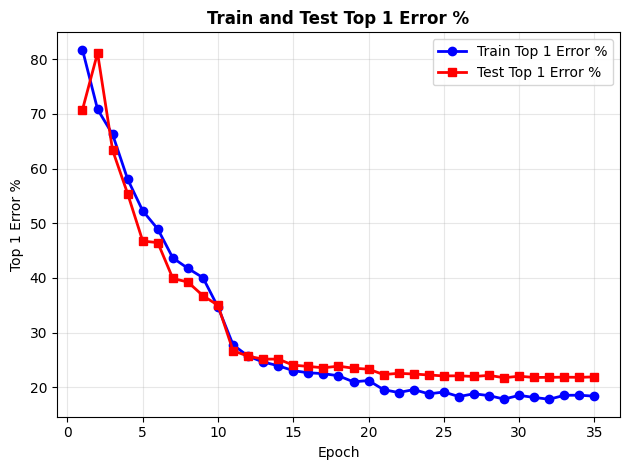

In [42]:
plot_loss(train_losses=D_train_top1_errors, test_losses=D_test_top1_errors, save_path="D_top1_errors.png", label="Top 1 Error %")

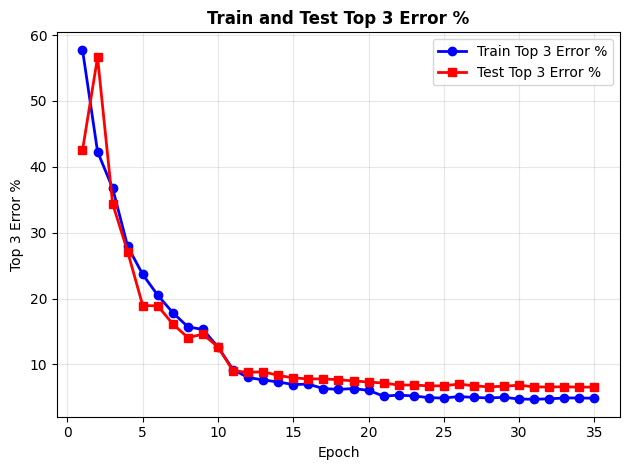

In [43]:
plot_loss(train_losses=D_train_top3_errors, test_losses=D_test_top3_errors, save_path="D_top3_errors.png", label="Top 3 Error %")

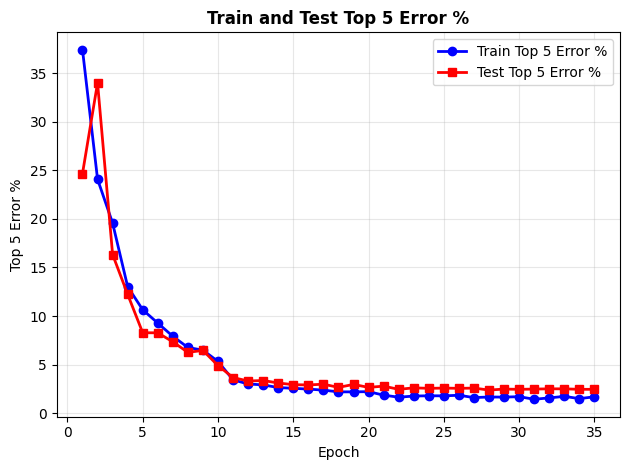

In [44]:
plot_loss(train_losses=D_train_top5_errors, test_losses=D_test_top5_errors, save_path="D_top5_errors.png", label="Top 5 Error %")

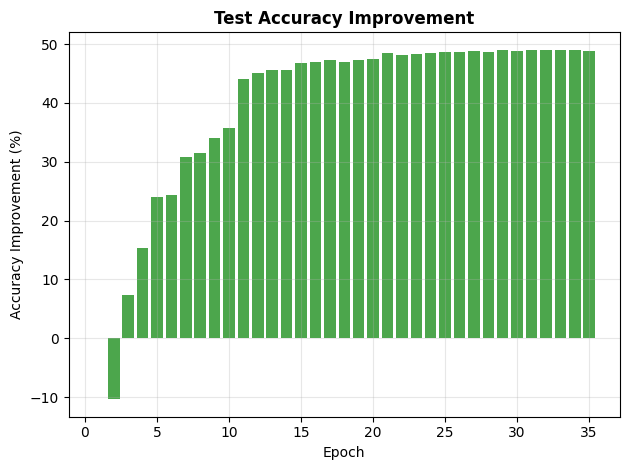

In [45]:
plot_accuracy_improvement(D_test_top1_errors, save_path="D_top1_error_improvement.png")

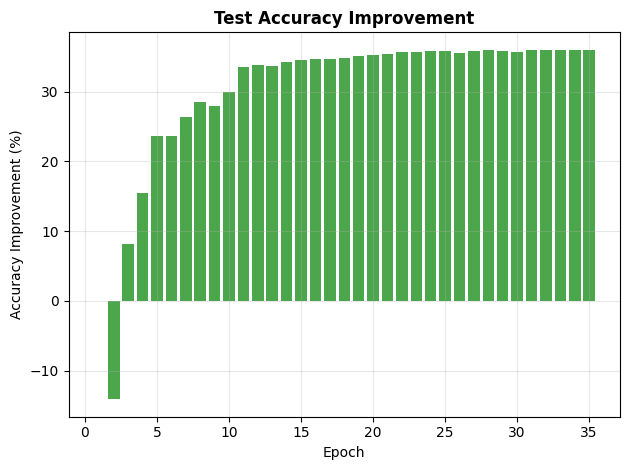

In [46]:
plot_accuracy_improvement(D_test_top3_errors, save_path="D_top3_error_improvement.png")

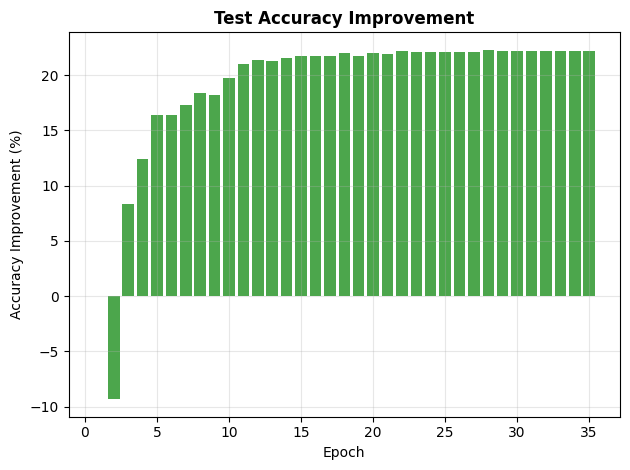

In [47]:
plot_accuracy_improvement(D_test_top5_errors, save_path="D_top5_error_improvement.png")